# AISO 강점 탐색: Multi-modal + Simplex 도메인
#
# Part 1: Multi-modal — 여러 최적점 동시 발견 (Peak Ratio)
# Part 2: Simplex    — Feature Weighting (GNN 구조)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

# Multi-modal 파라미터
N_AG_MM  = 40
N_IT_MM  = 200
N_RUN_MM = 20
PEAK_R   = 0.12   # 최적점 감지 반경

# Simplex 파라미터
K_FEAT   = 12
N_AG_SX  = 30
N_IT_SX  = 150
N_RUN_SX = 20

N_TYPES  = 12
BETA     = 0.08

np.random.seed(42)
print('설정 완료')

설정 완료


## Part 1: Multi-modal 탐색 — 여러 최적점 동시 발견

AISO 가설: 타입 다양성 → 에이전트가 서로 다른 클러스터로 자연 분리 → Peak Ratio ↑

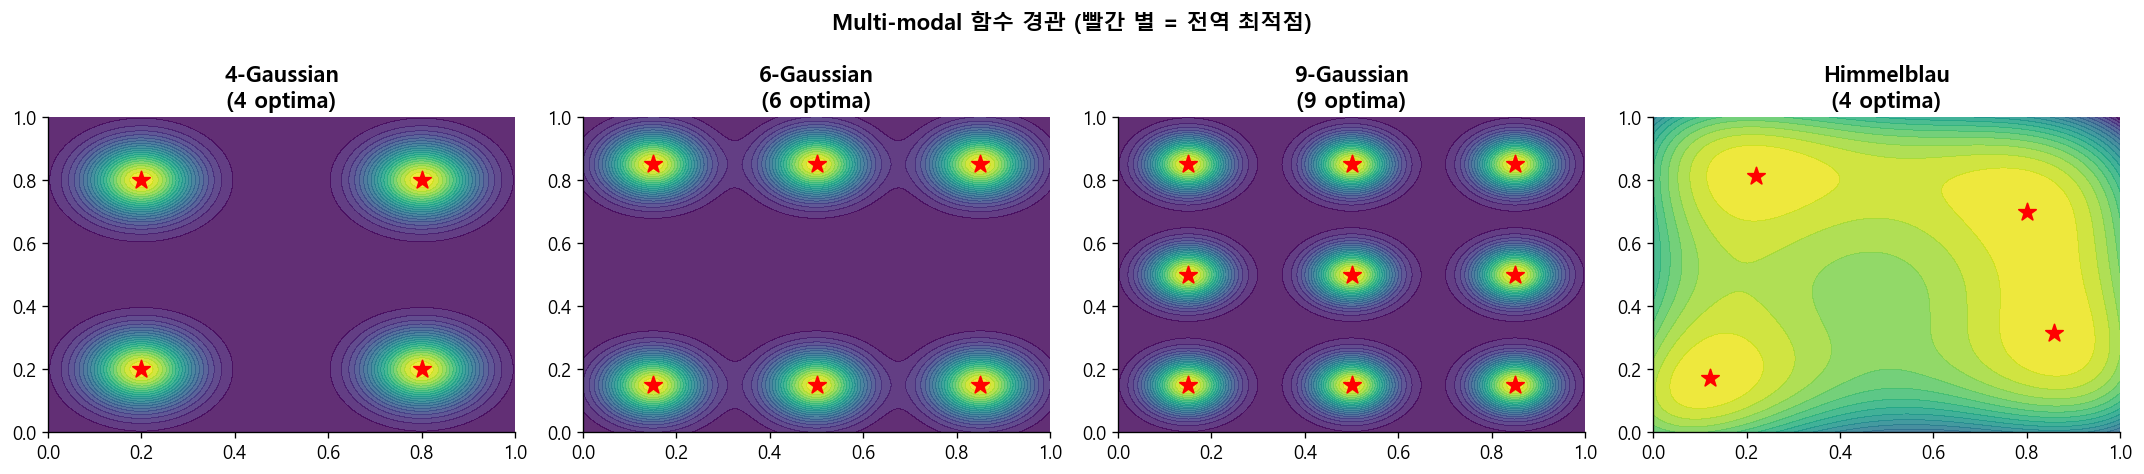

In [2]:
# ── Multi-modal 함수 ──────────────────────────────────────────
def make_gaussian_mixture(peaks, sigma=0.07):
    peaks = np.array(peaks)
    def f(x):
        x2 = np.array(x)[:2]
        return -float(sum(np.exp(-np.sum((x2-p)**2)/(2*sigma**2)) for p in peaks))
    f.__name__ = f'GM{len(peaks)}'
    return f, peaks

def make_himmelblau():
    optima_orig = np.array([[3.0,2.0],[-2.805118,3.131312],
                            [-3.779310,-3.283186],[3.584428,-1.848126]])
    optima = (optima_orig + 5) / 10   # [0,1]^2 정규화
    def f(x):
        z = np.array(x)[:2]*10-5
        return float((z[0]**2+z[1]-11)**2+(z[0]+z[1]**2-7)**2)
    f.__name__ = 'Himmelblau'
    return f, optima

PEAKS_4 = np.array([[0.2,0.2],[0.2,0.8],[0.8,0.2],[0.8,0.8]])
PEAKS_6 = np.array([[0.15,0.15],[0.15,0.85],[0.85,0.15],[0.85,0.85],[0.5,0.15],[0.5,0.85]])
PEAKS_9 = np.array([[i*0.35+0.15, j*0.35+0.15] for i in range(3) for j in range(3)])

GM4, OPT4  = make_gaussian_mixture(PEAKS_4, sigma=0.08)
GM6, OPT6  = make_gaussian_mixture(PEAKS_6, sigma=0.07)
GM9, OPT9  = make_gaussian_mixture(PEAKS_9, sigma=0.06)
HB,  OPTHB = make_himmelblau()

MULTIMODAL = [
    (GM4, OPT4,  '4-Gaussian'),
    (GM6, OPT6,  '6-Gaussian'),
    (GM9, OPT9,  '9-Gaussian'),
    (HB,  OPTHB, 'Himmelblau'),
]

# 경관 시각화
grid = np.linspace(0, 1, 100)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (fn, opts, name) in zip(axes, MULTIMODAL):
    Z = np.array([[fn([x,y]) for x in grid] for y in grid])
    ax.contourf(grid, grid, Z, levels=20, cmap='viridis_r', alpha=0.85)
    ax.scatter(opts[:,0], opts[:,1], c='red', s=120, marker='*', zorder=5)
    ax.set_title(f'{name}\n({len(opts)} optima)', fontweight='bold')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle('Multi-modal 함수 경관 (빨간 별 = 전역 최적점)', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_domains_landscapes.png', bbox_inches='tight')
plt.show()

In [3]:
# ── 유틸 + 알고리즘 ───────────────────────────────────────────
def peak_ratio(positions, optima, radius=PEAK_R):
    found = set()
    for pos in positions:
        for k, opt in enumerate(optima):
            if np.linalg.norm(np.array(pos) - opt) < radius:
                found.add(k)
    return len(found) / len(optima)

def diversity(positions):
    pos = np.array(positions); n = len(pos)
    d = [np.linalg.norm(pos[i]-pos[j]) for i in range(n) for j in range(i+1,n)]
    return float(np.mean(d)) if d else 0.

# AISO (v6c: Top-k 인력+척력, M∈[-1,2])
def run_aiso_mm(f, optima, seed, k=3, alpha=0.2):
    np.random.seed(seed)
    K=2; M=np.random.uniform(-1,2,(N_TYPES,N_TYPES))
    X=np.random.rand(N_AG_MM,K); W=np.random.dirichlet(np.ones(N_TYPES),N_AG_MM)
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    for _ in range(N_IT_MM):
        C=W@M@W.T; np.fill_diagonal(C,0)
        for i in range(N_AG_MM):
            ci=C[i].copy(); ci[i]=0
            top_a=np.argsort(ci)[-k:]; top_r=np.argsort(ci)[:k]
            Fv=sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv+=sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv/=(2*k); nX=np.clip(X[i]+alpha*Fv,0,1); ns=f(nX)
            if ns<S[i]:
                X[i]=nX; S[i]=ns
                bja=top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
    return X, S, peak_ratio(X,optima), diversity(X)

# PSO 표준
def run_pso_mm(f, optima, seed):
    np.random.seed(seed)
    K=2; w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG_MM,K); V=np.zeros((N_AG_MM,K))
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    pX=X.copy(); pS=S.copy(); gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    for _ in range(N_IT_MM):
        r1,r2=np.random.rand(N_AG_MM,K),np.random.rand(N_AG_MM,K)
        V=w*V+c1*r1*(pX-X)+c2*r2*(gX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(N_AG_MM)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
        if pS.min()<gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return X, S, peak_ratio(X,optima), diversity(X)

# PSO-Clearing (niching): 같은 niche에서 최상위 1명만 남기고 나머지 리셋
def run_pso_clearing(f, optima, seed, sigma=0.15, T_clr=10):
    np.random.seed(seed)
    K=2; w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG_MM,K); V=np.zeros((N_AG_MM,K))
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    pX=X.copy(); pS=S.copy(); gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    for it in range(N_IT_MM):
        r1,r2=np.random.rand(N_AG_MM,K),np.random.rand(N_AG_MM,K)
        V=w*V+c1*r1*(pX-X)+c2*r2*(gX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(N_AG_MM)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
        if pS.min()<gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
        if (it+1)%T_clr==0:
            dominated=set()
            for i in range(N_AG_MM):
                if i in dominated: continue
                for j in range(i+1,N_AG_MM):
                    if j in dominated: continue
                    if np.linalg.norm(pX[i]-pX[j])<sigma:
                        dominated.add(j if pS[i]<=pS[j] else i)
            for j in dominated:
                X[j]=np.random.rand(K); V[j]=np.zeros(K)
                S[j]=f(X[j]); pX[j]=X[j].copy(); pS[j]=S[j]
            gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return X, S, peak_ratio(X,optima), diversity(X)

# Random (동일 예산)
def run_random_mm(f, optima, seed):
    np.random.seed(seed)
    K=2; pos=np.random.rand(N_AG_MM*N_IT_MM,K)
    scores=np.array([f(pos[i]) for i in range(N_AG_MM*N_IT_MM)])
    top=np.argsort(scores)[:N_AG_MM]
    X=pos[top]; S=scores[top]
    return X, S, peak_ratio(X,optima), diversity(X)

MM_ALGOS = {'AISO':run_aiso_mm,'PSO':run_pso_mm,
            'PSO-Clearing':run_pso_clearing,'Random':run_random_mm}
print('알고리즘:', list(MM_ALGOS.keys()))

알고리즘: ['AISO', 'PSO', 'PSO-Clearing', 'Random']


In [4]:
# ── Multi-modal 벤치마크 실행 ─────────────────────────────────
mm_results = {}
for fn, opts, name in MULTIMODAL:
    print(f'\n── {name} ({len(opts)} optima) ──')
    mm_results[name] = {}
    for aname, afunc in MM_ALGOS.items():
        pr_list, div_list = [], []
        for r in range(N_RUN_MM):
            _, _, pr, dv = afunc(fn, opts, seed=42+r)
            pr_list.append(pr); div_list.append(dv)
        mm_results[name][aname] = {'pr': pr_list, 'div': div_list}
        print(f'  {aname:<14} PR={np.mean(pr_list):.3f}±{np.std(pr_list):.3f}  '
              f'div={np.mean(div_list):.3f}')
print('\n✓ 완료!')


── 4-Gaussian (4 optima) ──
  AISO           PR=0.988±0.054  div=0.429
  PSO            PR=0.250±0.000  div=0.004
  PSO-Clearing   PR=0.825±0.160  div=0.537
  Random         PR=1.000±0.000  div=0.519

── 6-Gaussian (6 optima) ──
  AISO           PR=0.917±0.099  div=0.462
  PSO            PR=0.200±0.067  div=0.018
  PSO-Clearing   PR=0.842±0.144  div=0.536
  Random         PR=1.000±0.000  div=0.561

── 9-Gaussian (9 optima) ──
  AISO           PR=0.928±0.073  div=0.445
  PSO            PR=0.139±0.048  div=0.019
  PSO-Clearing   PR=0.822±0.138  div=0.523
  Random         PR=0.994±0.024  div=0.508

── Himmelblau (4 optima) ──
  AISO           PR=0.925±0.115  div=0.401
  PSO            PR=0.325±0.115  div=0.030
  PSO-Clearing   PR=0.887±0.185  div=0.538
  Random         PR=1.000±0.000  div=0.465

✓ 완료!


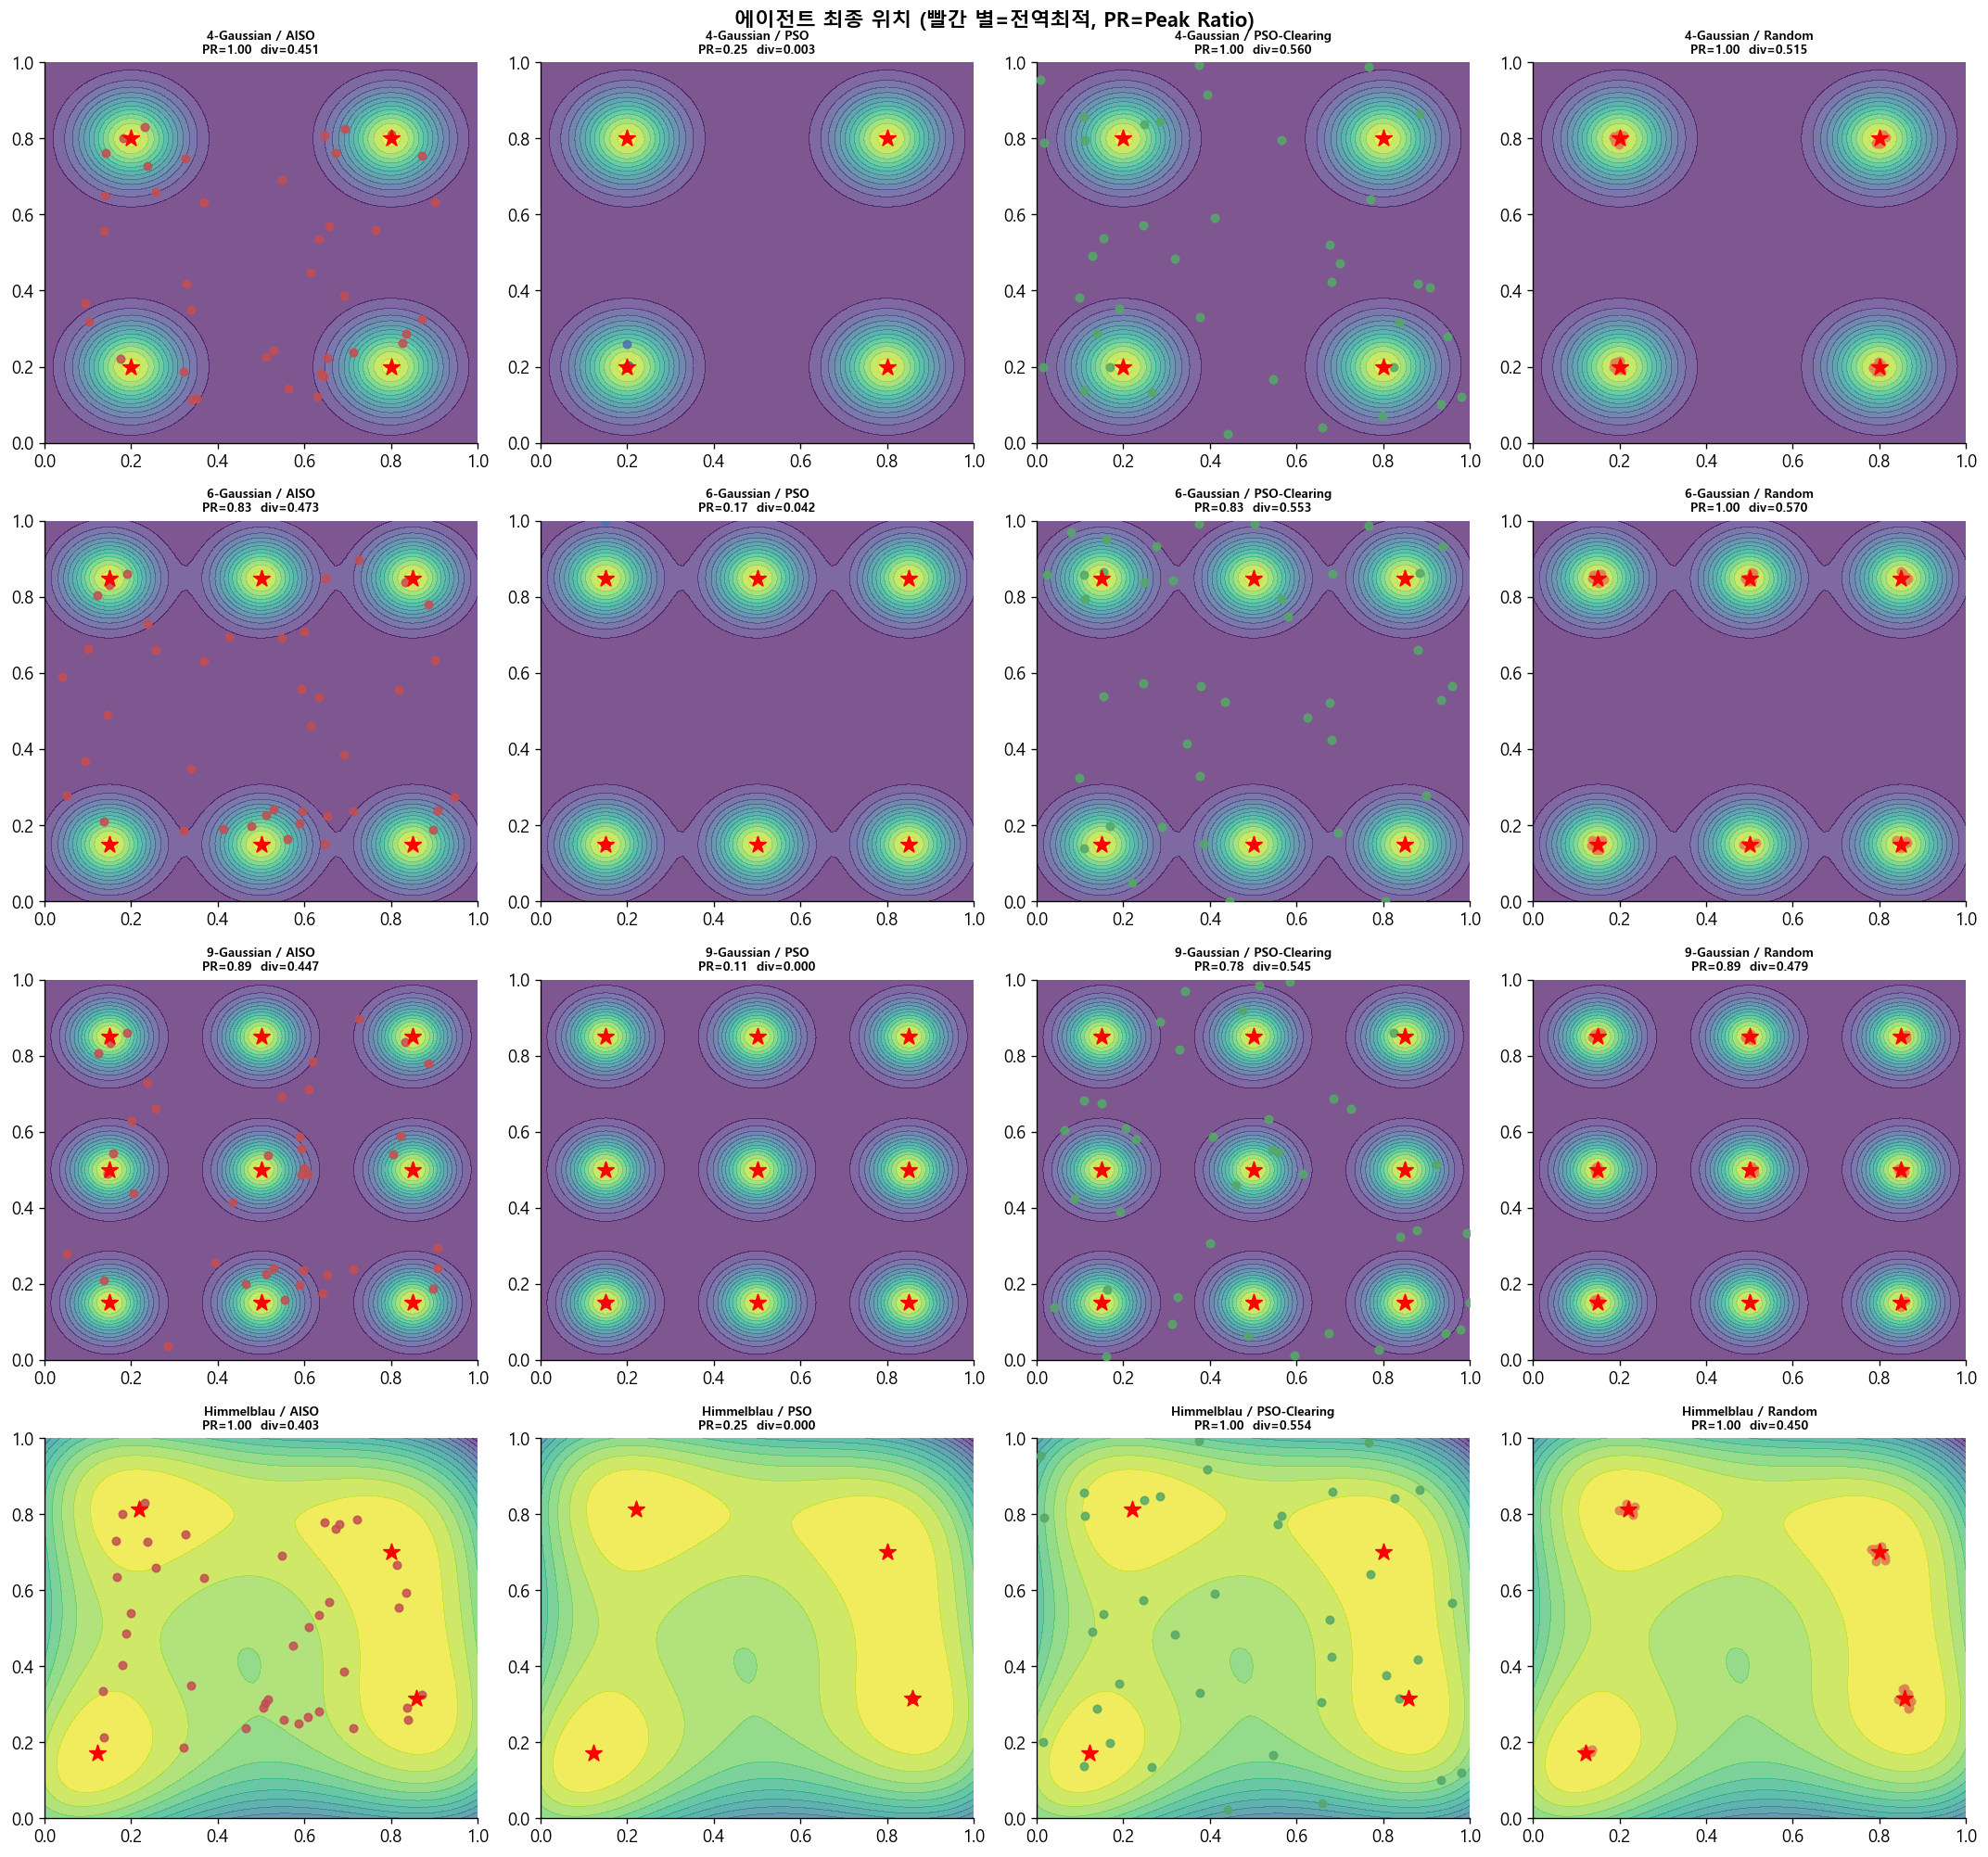

In [5]:
# ── 에이전트 위치 시각화 (단일 run) ──────────────────────────
COLORS = {'AISO':'#C44E52','PSO':'#4C72B0','PSO-Clearing':'#55A868','Random':'#DD8452'}
algo_list = list(MM_ALGOS.keys())
grid_v = np.linspace(0, 1, 80)

fig, axes = plt.subplots(4, 4, figsize=(18, 17))
for row, (fn, opts, name) in enumerate(MULTIMODAL):
    Z = np.array([[fn([x,y]) for x in grid_v] for y in grid_v])
    for col, aname in enumerate(algo_list):
        ax = axes[row][col]
        ax.contourf(grid_v, grid_v, Z, levels=15, cmap='viridis_r', alpha=0.7)
        X_f, _, pr, dv = MM_ALGOS[aname](fn, opts, seed=42)
        ax.scatter(X_f[:,0], X_f[:,1], c=COLORS[aname], s=25, zorder=5, alpha=0.85)
        ax.scatter(opts[:,0], opts[:,1], c='red', s=120, marker='*', zorder=6)
        ax.set_title(f'{name} / {aname}\nPR={pr:.2f}  div={dv:.3f}',
                     fontsize=8, fontweight='bold')
        ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle('에이전트 최종 위치 (빨간 별=전역최적, PR=Peak Ratio)', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_domains_mm_scatter.png', bbox_inches='tight')
plt.show()

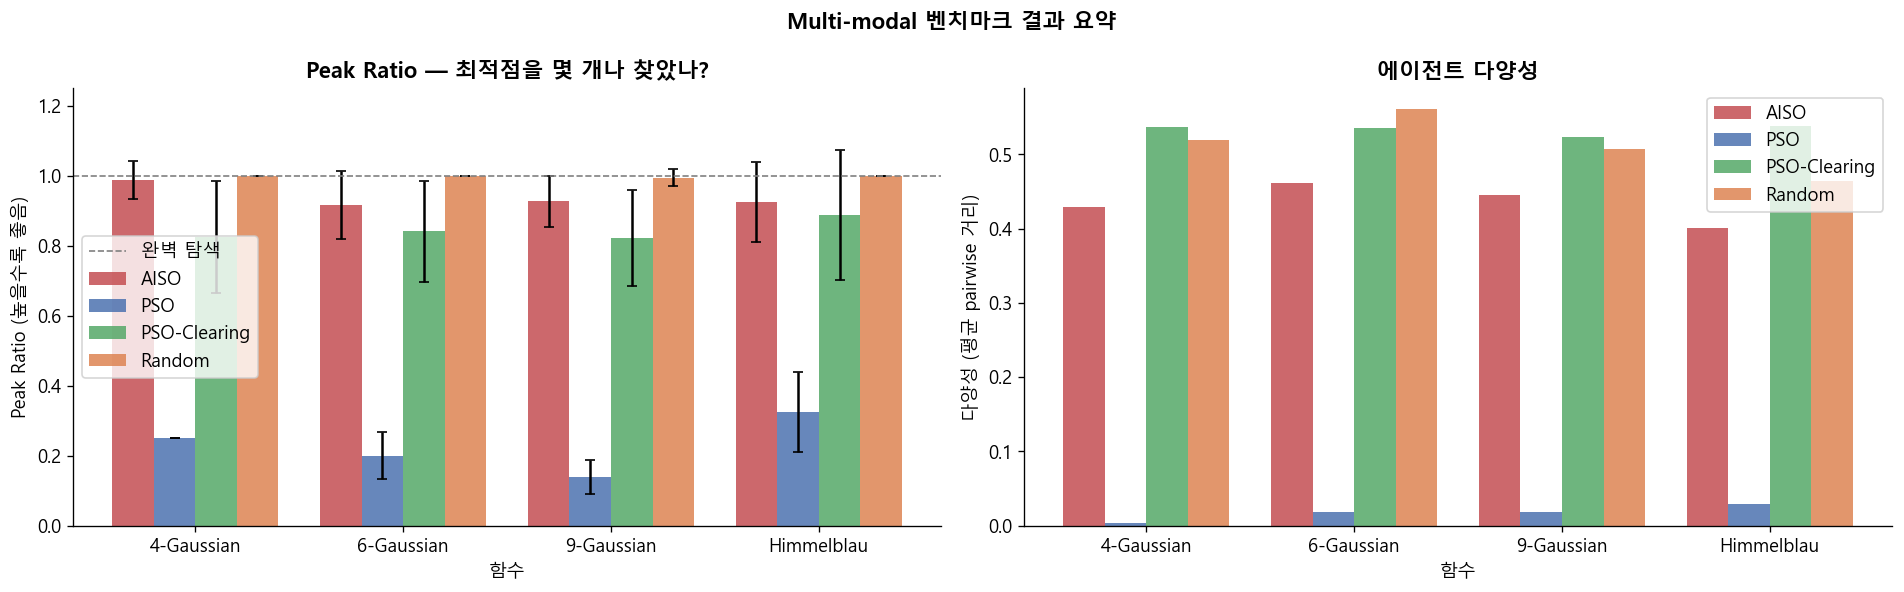


=== 알고리즘별 평균 Peak Ratio ===
  AISO          : PR=0.939  Diversity=0.434
  PSO           : PR=0.228  Diversity=0.018
  PSO-Clearing  : PR=0.844  Diversity=0.533
  Random        : PR=0.999  Diversity=0.513


In [6]:
# ── Peak Ratio + Diversity 바차트 ─────────────────────────────
fn_names = [n for _,_,n in MULTIMODAL]
x = np.arange(len(fn_names)); width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for k, aname in enumerate(algo_list):
    pr_means = [np.mean(mm_results[n][aname]['pr']) for n in fn_names]
    pr_stds  = [np.std(mm_results[n][aname]['pr'])  for n in fn_names]
    ax.bar(x+k*width, pr_means, width, label=aname,
           color=list(COLORS.values())[k], yerr=pr_stds, capsize=3, alpha=0.85)
ax.axhline(1.0, color='gray', ls='--', lw=1, label='완벽 탐색')
ax.set_xlabel('함수'); ax.set_ylabel('Peak Ratio (높을수록 좋음)')
ax.set_title('Peak Ratio — 최적점을 몇 개나 찾았나?', fontweight='bold')
ax.set_xticks(x+1.5*width); ax.set_xticklabels(fn_names)
ax.set_ylim(0, 1.25); ax.legend()

ax = axes[1]
for k, aname in enumerate(algo_list):
    div_means = [np.mean(mm_results[n][aname]['div']) for n in fn_names]
    ax.bar(x+k*width, div_means, width, label=aname,
           color=list(COLORS.values())[k], alpha=0.85)
ax.set_xlabel('함수'); ax.set_ylabel('다양성 (평균 pairwise 거리)')
ax.set_title('에이전트 다양성', fontweight='bold')
ax.set_xticks(x+1.5*width); ax.set_xticklabels(fn_names)
ax.legend()

plt.suptitle('Multi-modal 벤치마크 결과 요약', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_domains_mm_results.png', bbox_inches='tight')
plt.show()

print('\n=== 알고리즘별 평균 Peak Ratio ===')
for aname in algo_list:
    avg_pr  = np.mean([np.mean(mm_results[n][aname]['pr'])  for n in fn_names])
    avg_div = np.mean([np.mean(mm_results[n][aname]['div']) for n in fn_names])
    print(f'  {aname:<14}: PR={avg_pr:.3f}  Diversity={avg_div:.3f}')

## Part 2: Simplex 탐색 — Feature Weighting

해 공간 = 확률 단순형 Δ^{K-1}  
- 진짜 가중치 w* ~ Dirichlet(α) 생성  
- 점수 = MSE(X·w, y)  
- **AISO-simplex**: Sol[i](해) + T[i](타입) 분리, c_ij = T[i]^T M T[j]  
- **PSO-simplex**: 속도 기반 + 단순형 투영

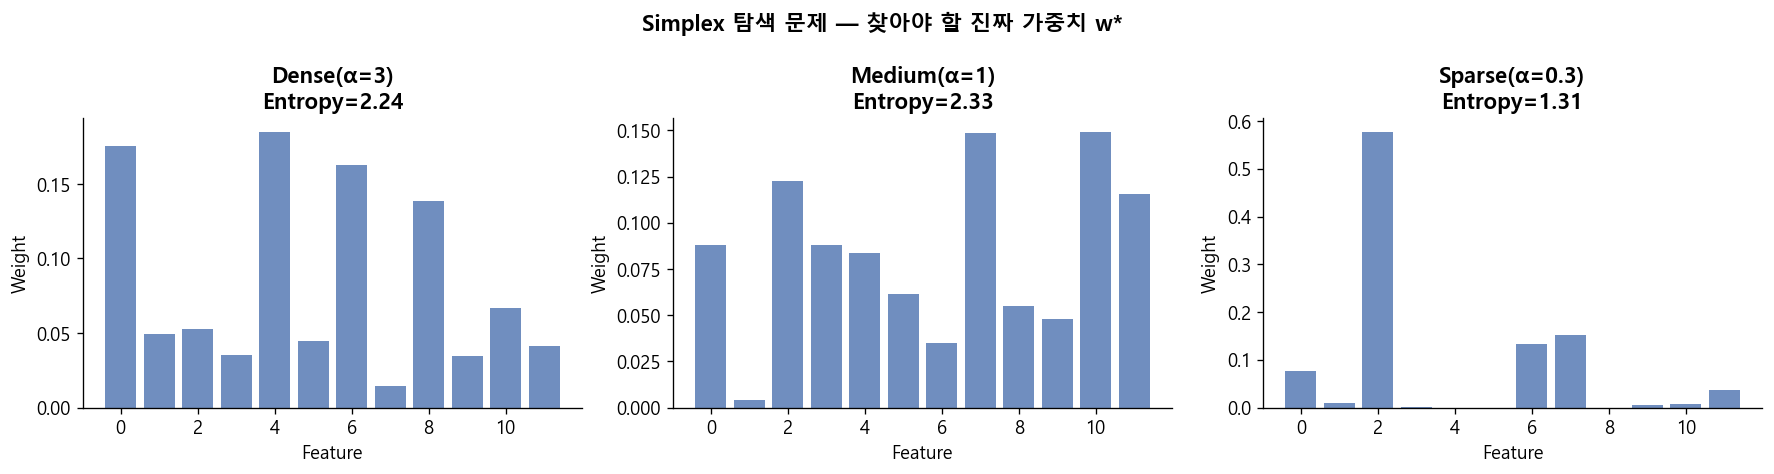

In [7]:
# ── Simplex 문제 생성 ─────────────────────────────────────────
def simplex_proj(w, eps=1e-10):
    w = np.clip(w, eps, None); return w / w.sum()

def make_regression(K=12, n_samples=200, alpha=1.0, noise=0.1, seed=0):
    np.random.seed(seed)
    w_true = np.random.dirichlet(alpha * np.ones(K))
    X = np.random.randn(n_samples, K)
    y = X @ w_true + noise * np.random.randn(n_samples)
    def score(w):
        w = simplex_proj(np.array(w, dtype=float))
        return float(np.mean((y - X @ w)**2))
    return score, w_true

REG_PROBLEMS = {
    'Dense(α=3)'   : make_regression(K_FEAT, alpha=3.0, seed=1),
    'Medium(α=1)'  : make_regression(K_FEAT, alpha=1.0, seed=2),
    'Sparse(α=0.3)': make_regression(K_FEAT, alpha=0.3, seed=3),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (_, w_true)) in zip(axes, REG_PROBLEMS.items()):
    ax.bar(range(K_FEAT), w_true, color='#4C72B0', alpha=0.8)
    ent = -np.sum(w_true * np.log(w_true + 1e-12))
    ax.set_title(f'{name}\nEntropy={ent:.2f}', fontweight='bold')
    ax.set_xlabel('Feature'); ax.set_ylabel('Weight')
plt.suptitle('Simplex 탐색 문제 — 찾아야 할 진짜 가중치 w*', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_domains_sx_problems.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Simplex 알고리즘 ──────────────────────────────────────────

# AISO-simplex: Sol(해) + T(타입) 분리, c_ij = T[i]^T M T[j]
def run_aiso_sx(score_fn, K, seed, k=3, alpha=0.3):
    np.random.seed(seed)
    M   = np.random.uniform(-1, 2, (N_TYPES, N_TYPES))
    Sol = np.array([simplex_proj(np.random.dirichlet(np.ones(K))) for _ in range(N_AG_SX)])
    T   = np.random.dirichlet(np.ones(N_TYPES), N_AG_SX)
    S   = np.array([score_fn(Sol[i]) for i in range(N_AG_SX)])
    bS  = S.min()
    for _ in range(N_IT_SX):
        C = T @ M @ T.T; np.fill_diagonal(C, 0)
        for i in range(N_AG_SX):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]; top_r = np.argsort(ci)[:k]
            Fv  = sum(ci[ja]*(Sol[ja]-Sol[i]) for ja in top_a)
            Fv += sum(ci[jr]*(Sol[jr]-Sol[i]) for jr in top_r)
            Fv /= (2*k)
            nSol = simplex_proj(Sol[i] + alpha*Fv); ns = score_fn(nSol)
            if ns < S[i]:
                Sol[i] = nSol; S[i] = ns
                bja = top_a[np.argmax(ci[top_a])]
                T[i] = (1-BETA)*T[i] + BETA*T[bja]; T[i] /= T[i].sum()
        if S.min() < bS: bS = S.min()
    bi = np.argmin(S)
    return bS, Sol[bi]

# PSO-simplex
def run_pso_sx(score_fn, K, seed):
    np.random.seed(seed)
    w_, c1, c2 = 0.729, 1.494, 1.494
    X  = np.array([simplex_proj(np.random.dirichlet(np.ones(K))) for _ in range(N_AG_SX)])
    V  = np.random.uniform(-0.05, 0.05, (N_AG_SX, K))
    S  = np.array([score_fn(X[i]) for i in range(N_AG_SX)])
    pX = X.copy(); pS = S.copy()
    gi = np.argmin(pS); gX = pX[gi].copy(); gS = pS[gi]
    for _ in range(N_IT_SX):
        r1, r2 = np.random.rand(N_AG_SX, K), np.random.rand(N_AG_SX, K)
        V  = w_*V + c1*r1*(pX-X) + c2*r2*(gX-X)
        X  = np.array([simplex_proj(X[i]+V[i]) for i in range(N_AG_SX)])
        S  = np.array([score_fn(X[i]) for i in range(N_AG_SX)])
        bt = S < pS; pX[bt] = X[bt]; pS[bt] = S[bt]
        if pS.min() < gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return gS, gX

# Random Dirichlet (동일 예산)
def run_random_sx(score_fn, K, seed):
    np.random.seed(seed)
    n_total = N_IT_SX * N_AG_SX
    W_samp  = np.array([simplex_proj(np.random.dirichlet(np.ones(K))) for _ in range(n_total)])
    scores  = np.array([score_fn(W_samp[i]) for i in range(n_total)])
    bi = np.argmin(scores)
    return scores[bi], W_samp[bi]

# Greedy hill-climbing
def run_greedy_sx(score_fn, K, seed):
    np.random.seed(seed)
    best_w = simplex_proj(np.random.dirichlet(np.ones(K)))
    best_s = score_fn(best_w)
    for _ in range(N_IT_SX):
        noise  = np.random.randn(N_AG_SX, K) * 0.1
        cands  = np.array([simplex_proj(best_w + noise[k]) for k in range(N_AG_SX)])
        scores = np.array([score_fn(cands[k]) for k in range(N_AG_SX)])
        mi = np.argmin(scores)
        if scores[mi] < best_s: best_s = scores[mi]; best_w = cands[mi]
    return best_s, best_w

SX_ALGOS = {
    'AISO-simplex': run_aiso_sx,
    'PSO-simplex' : run_pso_sx,
    'Random'      : run_random_sx,
    'Greedy'      : run_greedy_sx,
}
print('알고리즘:', list(SX_ALGOS.keys()))

알고리즘: ['AISO-simplex', 'PSO-simplex', 'Random', 'Greedy']


In [9]:
# ── Simplex 벤치마크 실행 ─────────────────────────────────────
sx_results = {}
for pname, (score_fn, w_true) in REG_PROBLEMS.items():
    print(f'\n── {pname} ──')
    sx_results[pname] = {}
    for aname, afunc in SX_ALGOS.items():
        mses = [afunc(score_fn, K_FEAT, seed=42+r)[0] for r in range(N_RUN_SX)]
        sx_results[pname][aname] = mses
        print(f'  {aname:<16} MSE={np.mean(mses):.5f}±{np.std(mses):.5f}')
print('\n✓ 완료!')


── Dense(α=3) ──
  AISO-simplex     MSE=0.03945±0.01103
  PSO-simplex      MSE=0.01040±0.00130
  Random           MSE=0.02028±0.00257
  Greedy           MSE=0.01566±0.00142

── Medium(α=1) ──
  AISO-simplex     MSE=0.02733±0.00566
  PSO-simplex      MSE=0.00862±0.00080
  Random           MSE=0.01949±0.00292
  Greedy           MSE=0.01469±0.00157

── Sparse(α=0.3) ──
  AISO-simplex     MSE=0.15591±0.05922
  PSO-simplex      MSE=0.01083±0.00355
  Random           MSE=0.04493±0.00845
  Greedy           MSE=0.01167±0.00095

✓ 완료!


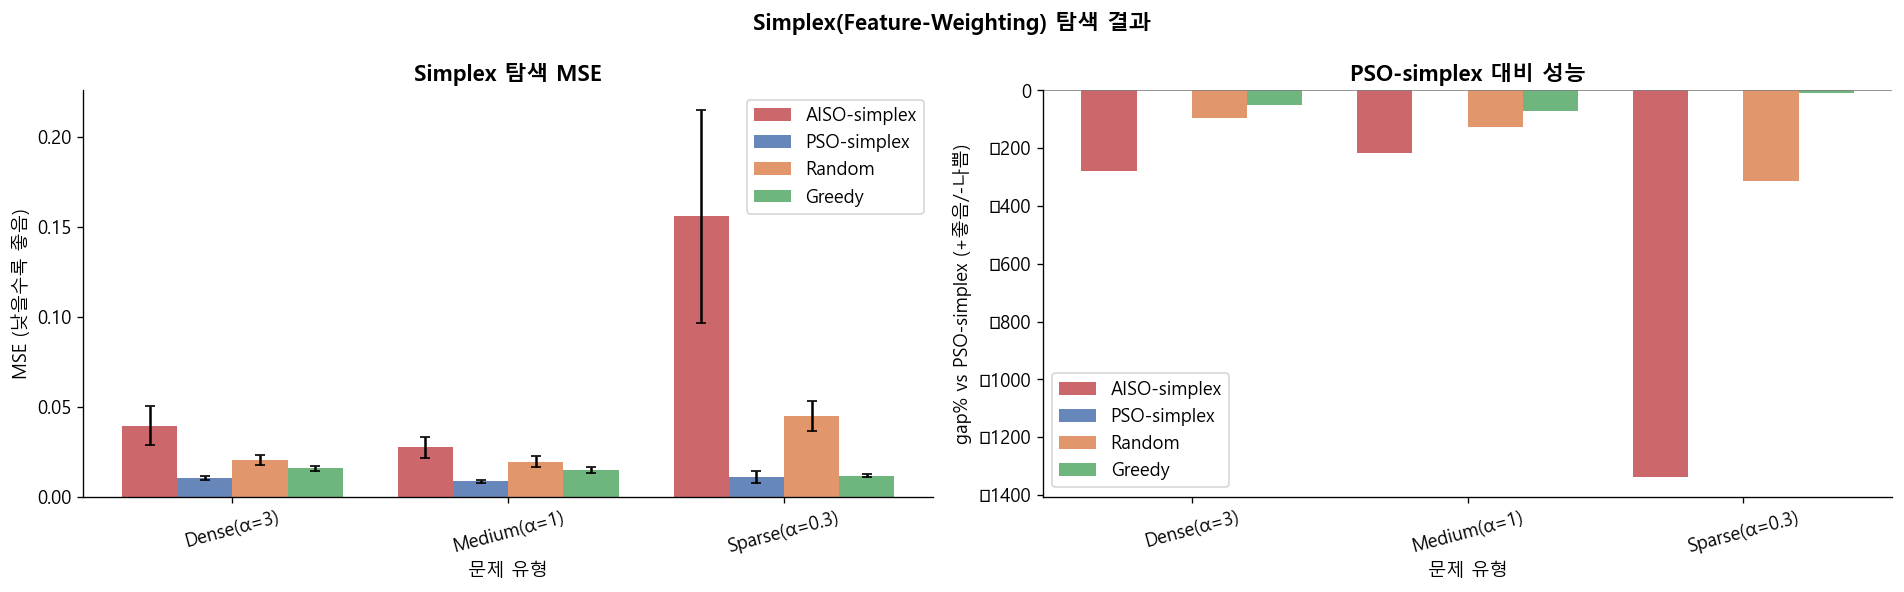


=== PSO-simplex 대비 승수 ===
  AISO-simplex    : 0/3승  avg gap -611.9%
  PSO-simplex     : 0/3승  avg gap +0.0%
  Random          : 0/3승  avg gap -178.7%
  Greedy          : 0/3승  avg gap -42.9%


In [10]:
# ── Simplex 결과 시각화 ────────────────────────────────────────
prob_names    = list(REG_PROBLEMS.keys())
sx_algo_names = list(SX_ALGOS.keys())
SX_COLORS = {'AISO-simplex':'#C44E52','PSO-simplex':'#4C72B0',
             'Random':'#DD8452','Greedy':'#55A868'}
x = np.arange(len(prob_names)); width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for k, aname in enumerate(sx_algo_names):
    means = [np.mean(sx_results[pn][aname]) for pn in prob_names]
    stds  = [np.std(sx_results[pn][aname])  for pn in prob_names]
    ax.bar(x+k*width, means, width, label=aname,
           color=SX_COLORS[aname], yerr=stds, capsize=3, alpha=0.85)
ax.set_xlabel('문제 유형'); ax.set_ylabel('MSE (낮을수록 좋음)')
ax.set_title('Simplex 탐색 MSE', fontweight='bold')
ax.set_xticks(x+1.5*width); ax.set_xticklabels(prob_names, rotation=15)
ax.legend()

ax = axes[1]
for k, aname in enumerate(sx_algo_names):
    gaps = [-(np.mean(sx_results[pn][aname])-np.mean(sx_results[pn]['PSO-simplex']))
            /(abs(np.mean(sx_results[pn]['PSO-simplex']))+1e-12)*100
            for pn in prob_names]
    ax.bar(x+k*width, gaps, width, label=aname, color=SX_COLORS[aname], alpha=0.85)
ax.axhline(0, color='gray', lw=1)
ax.set_xlabel('문제 유형'); ax.set_ylabel('gap% vs PSO-simplex (+좋음/-나쁨)')
ax.set_title('PSO-simplex 대비 성능', fontweight='bold')
ax.set_xticks(x+1.5*width); ax.set_xticklabels(prob_names, rotation=15)
ax.legend()

plt.suptitle('Simplex(Feature-Weighting) 탐색 결과', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_domains_sx_results.png', bbox_inches='tight')
plt.show()

print('\n=== PSO-simplex 대비 승수 ===')
for aname in sx_algo_names:
    wins  = sum(np.mean(sx_results[pn][aname]) < np.mean(sx_results[pn]['PSO-simplex'])
                for pn in prob_names)
    avg_g = np.mean([-(np.mean(sx_results[pn][aname])-np.mean(sx_results[pn]['PSO-simplex']))
                     /(abs(np.mean(sx_results[pn]['PSO-simplex']))+1e-12)*100
                     for pn in prob_names])
    print(f'  {aname:<16}: {wins}/{len(prob_names)}승  avg gap {avg_g:+.1f}%')

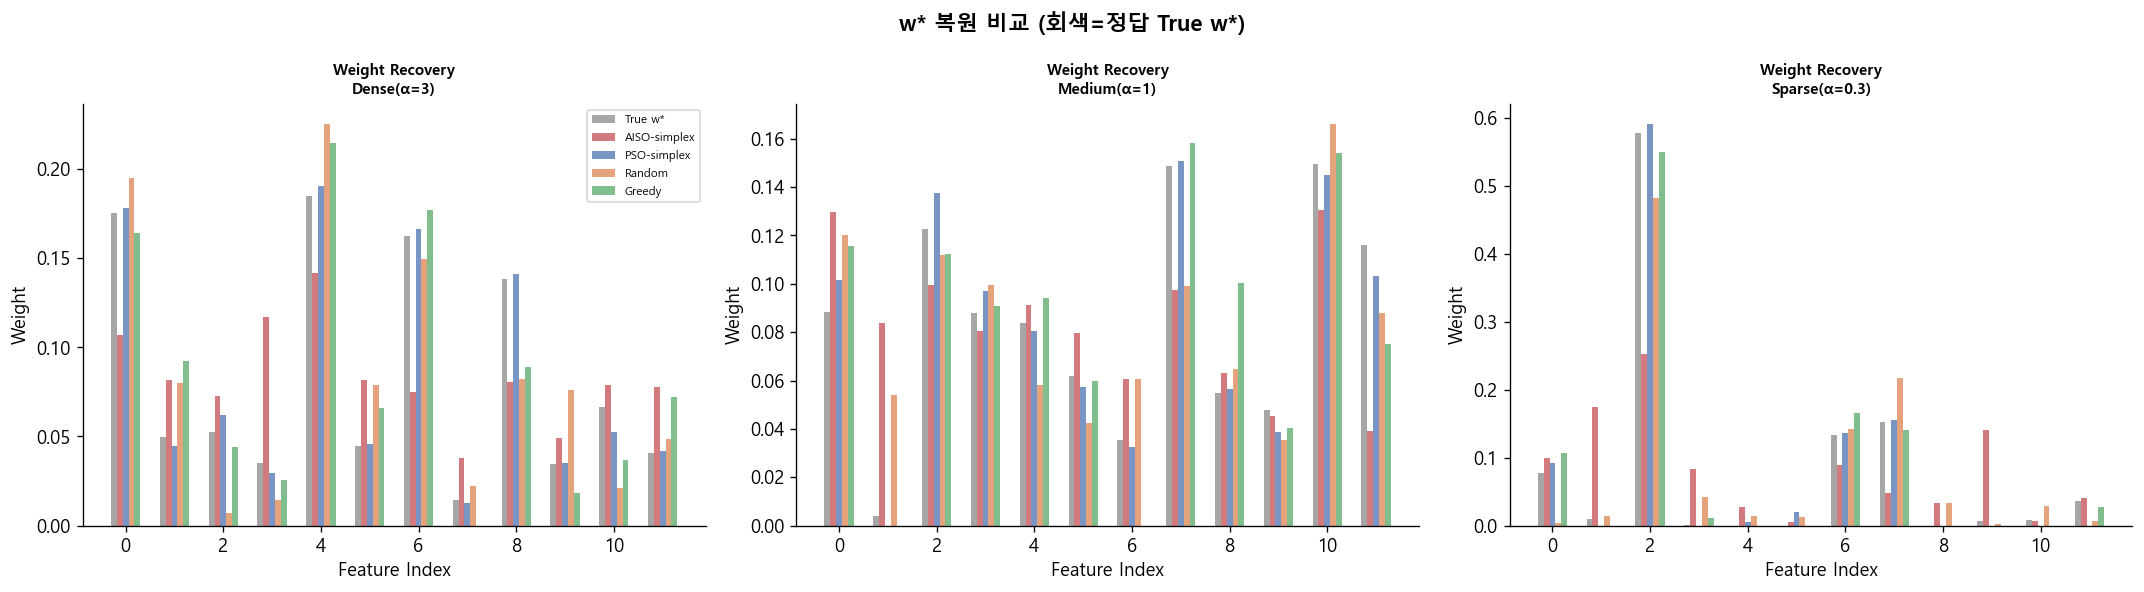

In [11]:
# ── Weight Recovery 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (pname, (score_fn, w_true)) in zip(axes, REG_PROBLEMS.items()):
    bar_w = 0.12; x_feat = np.arange(K_FEAT)
    ax.bar(x_feat - 2*bar_w, w_true, bar_w, label='True w*', color='gray', alpha=0.7)
    for k, (aname, afunc) in enumerate(SX_ALGOS.items()):
        _, w_found = afunc(score_fn, K_FEAT, seed=42)
        ax.bar(x_feat + (k-1)*bar_w, w_found, bar_w,
               label=aname, color=list(SX_COLORS.values())[k], alpha=0.75)
    ax.set_title(f'Weight Recovery\n{pname}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Feature Index'); ax.set_ylabel('Weight')
    if ax is axes[0]: ax.legend(fontsize=7)
plt.suptitle('w* 복원 비교 (회색=정답 True w*)', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_domains_weight_recovery.png', bbox_inches='tight')
plt.show()

In [12]:
# ── 최종 요약 ─────────────────────────────────────────────────
print('='*65)
print('  AISO 강점 도메인 최종 결과')
print('='*65)

fn_names2 = [n for _,_,n in MULTIMODAL]
print('\n[Part 1] Multi-modal Peak Ratio (높을수록 좋음)')
for aname in algo_list:
    vals = [np.mean(mm_results[n][aname]['pr']) for n in fn_names2]
    row  = '  '.join(f'{v:.2f}' for v in vals)
    print(f'  {aname:<14}  {row}  →  avg={np.mean(vals):.3f}')

print('\n[Part 2] Simplex MSE 승수 vs PSO-simplex')
for aname in sx_algo_names:
    wins  = sum(np.mean(sx_results[pn][aname]) < np.mean(sx_results[pn]['PSO-simplex'])
                for pn in prob_names)
    avg_g = np.mean([-(np.mean(sx_results[pn][aname])-np.mean(sx_results[pn]['PSO-simplex']))
                     /(abs(np.mean(sx_results[pn]['PSO-simplex']))+1e-12)*100
                     for pn in prob_names])
    print(f'  {aname:<16}: {wins}/{len(prob_names)}승  avg gap {avg_g:+.1f}%')
print('='*65)

  AISO 강점 도메인 최종 결과

[Part 1] Multi-modal Peak Ratio (높을수록 좋음)
  AISO            0.99  0.92  0.93  0.93  →  avg=0.939
  PSO             0.25  0.20  0.14  0.33  →  avg=0.228
  PSO-Clearing    0.82  0.84  0.82  0.89  →  avg=0.844
  Random          1.00  1.00  0.99  1.00  →  avg=0.999

[Part 2] Simplex MSE 승수 vs PSO-simplex
  AISO-simplex    : 0/3승  avg gap -611.9%
  PSO-simplex     : 0/3승  avg gap +0.0%
  Random          : 0/3승  avg gap -178.7%
  Greedy          : 0/3승  avg gap -42.9%


## SOTA 비교 — Multi-modal 전용 알고리즘

| 알고리즘 | 핵심 아이디어 |
|---|---|
| **lbest PSO** | 전체 gbest 대신 k개 이웃의 local best → 자연스럽게 여러 swarm 형성 |
| **Species-based PSO (SPSO)** | 에이전트를 species로 군집화, 각 species가 독립 peak 탐색 |
| **Crowding DE** | trial vector를 가장 비슷한 개체와 경쟁 → population 다양성 유지 |
| **Multiswarm PSO** | N/K 크기 swarm K개 독립 운영 |

In [13]:
# ── lbest PSO (Ring topology) ─────────────────────────────────
# 각 에이전트의 gbest = k개 이웃 중 best p_best
# 전체 수렴 없이 여러 subswarm이 자연 형성됨
def run_lbest_pso(f, optima, seed, k=3):
    np.random.seed(seed)
    K=2; w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG_MM,K); V=np.zeros((N_AG_MM,K))
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    pX=X.copy(); pS=S.copy()
    for _ in range(N_IT_MM):
        # 이웃 거리 기반 local best
        D = np.array([[np.linalg.norm(pX[i]-pX[j]) for j in range(N_AG_MM)]
                      for i in range(N_AG_MM)])
        for i in range(N_AG_MM):
            nbrs = np.argsort(D[i])[:k+1]          # 자신 포함 k+1
            li   = nbrs[np.argmin(pS[nbrs])]        # local best
            r1,r2 = np.random.rand(K), np.random.rand(K)
            V[i] = w*V[i]+c1*r1*(pX[i]-X[i])+c2*r2*(pX[li]-X[i])
            X[i] = np.clip(X[i]+V[i], 0, 1)
        S=np.array([f(X[i]) for i in range(N_AG_MM)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
    return X, S, peak_ratio(X,optima), diversity(X)


# ── Species-based PSO (SPSO) ──────────────────────────────────
# p_best 기준 정렬 → 반경 r 내 에이전트를 같은 species로 묶음
# 각 species는 자기 seed(best)를 향해 수렴
def run_spso(f, optima, seed, r_species=0.2):
    np.random.seed(seed)
    K=2; w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG_MM,K); V=np.zeros((N_AG_MM,K))
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    pX=X.copy(); pS=S.copy()
    for _ in range(N_IT_MM):
        # Species seed 결정
        order = np.argsort(pS)          # 좋은 것 먼저
        assigned = np.zeros(N_AG_MM, dtype=bool)
        seed_map = np.zeros(N_AG_MM, dtype=int)
        seeds = []
        for i in order:
            if not assigned[i]:
                seeds.append(i)
                for j in range(N_AG_MM):
                    if np.linalg.norm(pX[i]-pX[j]) < r_species:
                        assigned[j] = True
                        seed_map[j] = i
        # 각 에이전트 → species seed 방향으로 이동
        for i in range(N_AG_MM):
            gX_i = pX[seed_map[i]]
            r1,r2 = np.random.rand(K), np.random.rand(K)
            V[i] = w*V[i]+c1*r1*(pX[i]-X[i])+c2*r2*(gX_i-X[i])
            X[i] = np.clip(X[i]+V[i], 0, 1)
        S=np.array([f(X[i]) for i in range(N_AG_MM)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
    return X, S, peak_ratio(X,optima), diversity(X)


# ── Crowding DE ───────────────────────────────────────────────
# trial vector를 생성 후 population 중 가장 유사한 개체와 경쟁
# → 같은 niche 안에서만 교체 → 다양성 자동 유지
def run_crowding_de(f, optima, seed, F=0.5, CR=0.9):
    np.random.seed(seed)
    K=2
    X=np.random.rand(N_AG_MM,K)
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    for _ in range(N_IT_MM):
        for i in range(N_AG_MM):
            pool = [j for j in range(N_AG_MM) if j!=i]
            r1,r2,r3 = np.random.choice(pool, 3, replace=False)
            mutant = np.clip(X[r1]+F*(X[r2]-X[r3]), 0, 1)
            mask   = np.random.rand(K) < CR
            trial  = np.where(mask, mutant, X[i])
            # 가장 비슷한 개체 찾기 (crowding)
            dists  = np.array([np.linalg.norm(X[j]-trial) for j in range(N_AG_MM)])
            dists[i] = np.inf
            crowd  = np.argmin(dists)
            ns = f(trial)
            if ns < S[crowd]:
                X[crowd]=trial; S[crowd]=ns
    return X, S, peak_ratio(X,optima), diversity(X)


# ── Multiswarm PSO ────────────────────────────────────────────
# N개 에이전트를 K개 독립 swarm으로 분할, 각자 peak 탐색
def run_multiswarm(f, optima, seed, n_swarms=8):
    np.random.seed(seed)
    K=2; w,c1,c2=0.729,1.494,1.494
    aps = N_AG_MM // n_swarms    # agents per swarm
    X=np.random.rand(N_AG_MM,K); V=np.zeros((N_AG_MM,K))
    S=np.array([f(X[i]) for i in range(N_AG_MM)])
    pX=X.copy(); pS=S.copy()
    for _ in range(N_IT_MM):
        for sw in range(n_swarms):
            sl = slice(sw*aps, (sw+1)*aps)
            gi = np.argmin(pS[sl])
            gX_sw = pX[sw*aps+gi]
            r1=np.random.rand(aps,K); r2=np.random.rand(aps,K)
            V[sl]=w*V[sl]+c1*r1*(pX[sl]-X[sl])+c2*r2*(gX_sw-X[sl])
            X[sl]=np.clip(X[sl]+V[sl],0,1)
        S=np.array([f(X[i]) for i in range(N_AG_MM)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
    return X, S, peak_ratio(X,optima), diversity(X)


SOTA_ALGOS = {
    'lbest-PSO'    : run_lbest_pso,
    'SPSO'         : run_spso,
    'Crowding-DE'  : run_crowding_de,
    'Multiswarm'   : run_multiswarm,
}
print('SOTA 알고리즘:', list(SOTA_ALGOS.keys()))

SOTA 알고리즘: ['lbest-PSO', 'SPSO', 'Crowding-DE', 'Multiswarm']


In [14]:
# ── SOTA 벤치마크 실행 ────────────────────────────────────────
sota_results = {}
for fn, opts, name in MULTIMODAL:
    print(f'\n── {name} ({len(opts)} optima) ──')
    sota_results[name] = {}
    for aname, afunc in SOTA_ALGOS.items():
        pr_list, div_list = [], []
        for r in range(N_RUN_MM):
            _, _, pr, dv = afunc(fn, opts, seed=42+r)
            pr_list.append(pr); div_list.append(dv)
        sota_results[name][aname] = {'pr': pr_list, 'div': div_list}
        print(f'  {aname:<14} PR={np.mean(pr_list):.3f}±{np.std(pr_list):.3f}  '
              f'div={np.mean(div_list):.3f}')
print('\n✓ 완료!')


── 4-Gaussian (4 optima) ──
  lbest-PSO      PR=0.963±0.089  div=0.502
  SPSO           PR=1.000±0.000  div=0.511
  Crowding-DE    PR=1.000±0.000  div=0.515
  Multiswarm     PR=0.863±0.124  div=0.458

── 6-Gaussian (6 optima) ──
  lbest-PSO      PR=0.850±0.090  div=0.530
  SPSO           PR=0.992±0.036  div=0.544
  Crowding-DE    PR=1.000±0.000  div=0.558
  Multiswarm     PR=0.783±0.119  div=0.503

── 9-Gaussian (9 optima) ──
  lbest-PSO      PR=0.689±0.097  div=0.472
  SPSO           PR=0.956±0.054  div=0.510
  Crowding-DE    PR=1.000±0.000  div=0.503
  Multiswarm     PR=0.606±0.124  div=0.436

── Himmelblau (4 optima) ──
  lbest-PSO      PR=1.000±0.000  div=0.490
  SPSO           PR=1.000±0.000  div=0.500
  Crowding-DE    PR=1.000±0.000  div=0.504
  Multiswarm     PR=0.887±0.124  div=0.439

✓ 완료!


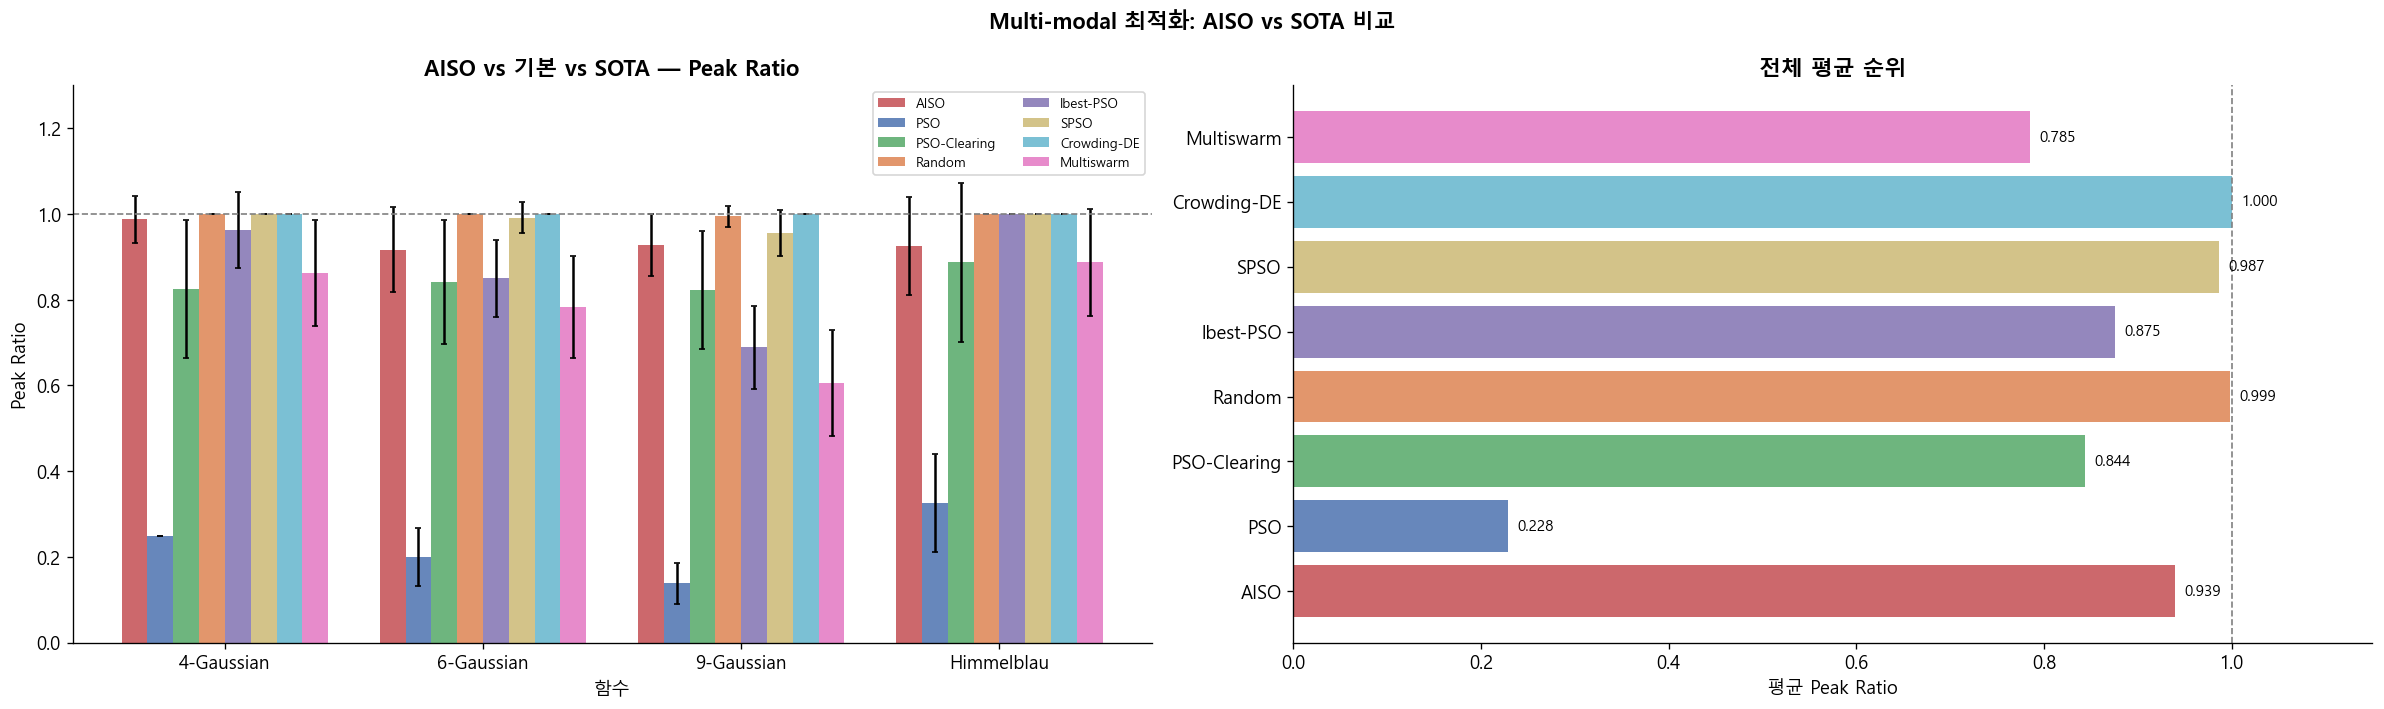


=== 최종 순위 (평균 Peak Ratio) ===
  1위  Crowding-DE   : 1.000
  2위  Random        : 0.999
  3위  SPSO          : 0.987
  4위  AISO          : 0.939 ← AISO
  5위  lbest-PSO     : 0.875
  6위  PSO-Clearing  : 0.844
  7위  Multiswarm    : 0.785
  8위  PSO           : 0.228


In [15]:
# ── 전체 비교 차트 (AISO vs 기본 vs SOTA) ────────────────────
all_algos = {**MM_ALGOS, **SOTA_ALGOS}
all_colors = {
    'AISO'        : '#C44E52',
    'PSO'         : '#4C72B0',
    'PSO-Clearing': '#55A868',
    'Random'      : '#DD8452',
    'lbest-PSO'   : '#8172B2',
    'SPSO'        : '#CCB974',
    'Crowding-DE' : '#64B5CD',
    'Multiswarm'  : '#E377C2',
}

# mm_results + sota_results 합치기
combined = {}
for name in fn_names:
    combined[name] = {**mm_results[name], **sota_results[name]}

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
x = np.arange(len(fn_names)); width = 0.1
algo_order = list(all_colors.keys())

ax = axes[0]
for k, aname in enumerate(algo_order):
    pr_means = [np.mean(combined[n][aname]['pr']) for n in fn_names]
    pr_stds  = [np.std(combined[n][aname]['pr'])  for n in fn_names]
    ax.bar(x+k*width, pr_means, width, label=aname,
           color=all_colors[aname], yerr=pr_stds, capsize=2, alpha=0.85)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('함수'); ax.set_ylabel('Peak Ratio')
ax.set_title('AISO vs 기본 vs SOTA — Peak Ratio', fontweight='bold')
ax.set_xticks(x+3.5*width); ax.set_xticklabels(fn_names)
ax.set_ylim(0, 1.3); ax.legend(ncol=2, fontsize=8)

ax = axes[1]
for k, aname in enumerate(algo_order):
    avg_pr = np.mean([np.mean(combined[n][aname]['pr']) for n in fn_names])
    ax.barh(k, avg_pr, color=all_colors[aname], alpha=0.85)
    ax.text(avg_pr+0.01, k, f'{avg_pr:.3f}', va='center', fontsize=9)
ax.axvline(1.0, color='gray', ls='--', lw=1)
ax.set_yticks(range(len(algo_order))); ax.set_yticklabels(algo_order)
ax.set_xlabel('평균 Peak Ratio')
ax.set_title('전체 평균 순위', fontweight='bold')
ax.set_xlim(0, 1.15)

plt.suptitle('Multi-modal 최적화: AISO vs SOTA 비교', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('aiso_sota_comparison.png', bbox_inches='tight')
plt.show()

print('\n=== 최종 순위 (평균 Peak Ratio) ===')
ranking = sorted(algo_order,
                 key=lambda a: np.mean([np.mean(combined[n][a]['pr']) for n in fn_names]),
                 reverse=True)
for rank, aname in enumerate(ranking, 1):
    avg = np.mean([np.mean(combined[n][aname]['pr']) for n in fn_names])
    tag = ' ← AISO' if aname == 'AISO' else ''
    print(f'  {rank}위  {aname:<14}: {avg:.3f}{tag}')